# ROC Curve

Conda environment for this notebook is in `development/plots/environment.yml`

Based on [HLS4ML tutorial plotting.py](https://github.com/fastmachinelearning/hls4ml-tutorial/blob/main/plotting.py)


In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import plotting

# standardize colors
from cycler import cycler 
colors = [ "#3e6990", "#aabd8c", "#8a8565", "#f39b6d","#381d2a",]
plt.rcParams['axes.prop_cycle'] = cycler('color', colors)

# Fonts match with latex
matplotlib.rcParams.update({
    'font.family': 'serif',
})

Overlapping comparison of baseline and quantized and ondboard verification

In [14]:
prediction_dir = 'predictions/'

y_true = np.load("processed_data/y_test.npy").astype('float32')
#y_true = np.load("processed_data/y_test.npy")
y_baseline = np.load("y_baseline.npy").astype('float32') # generated from baseline keras model
classes = ["C1", "C2", "C3"]
np.count_nonzero(y_true)

np.int64(413034)

In [15]:
y_check = np.load("predictions/y_dut_Training_AdaptiveHP_acc=0.7084_ebops=864_VU_DA_bitfile.npy")
y_check

array([[ 1.75   ,  0.25   , -1.375  ],
       [ 3.     ,  0.375  , -1.71875],
       [ 3.     ,  0.375  , -1.71875],
       ...,
       [ 0.     ,  0.     ,  0.     ],
       [ 0.     ,  0.     ,  0.     ],
       [ 0.     ,  0.     ,  0.     ]], shape=(413034, 3), dtype=float32)

In [16]:
def dut_roc(prediction_path, plotname):
    y_dut = np.load(prediction_path)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    _ = plotting.makeRoc(y_true, y_baseline, classes, linestyle="-")
    plt.gca().set_prop_cycle(None)  # reset the colors
    _ = plotting.makeRoc(y_true, y_dut, classes, linestyle="--")
    plt.gca().set_prop_cycle(None)  # reset the colors
    #ax.set_title("Logarithmic x-axis", size='x-large')

    plt.suptitle(plotname, size = 'xx-large')#, weight = 'bold')
    plt.tight_layout()
    plt.show()

    fig.savefig(f"export/ROC_{plotname.lower()}.pdf", format='pdf', bbox_inches="tight")

Searching for predictions in predictions/
predictions/y_dut_Training_AdaptiveHP_acc=0.7084_ebops=864_VU_DA_bitfile.npy


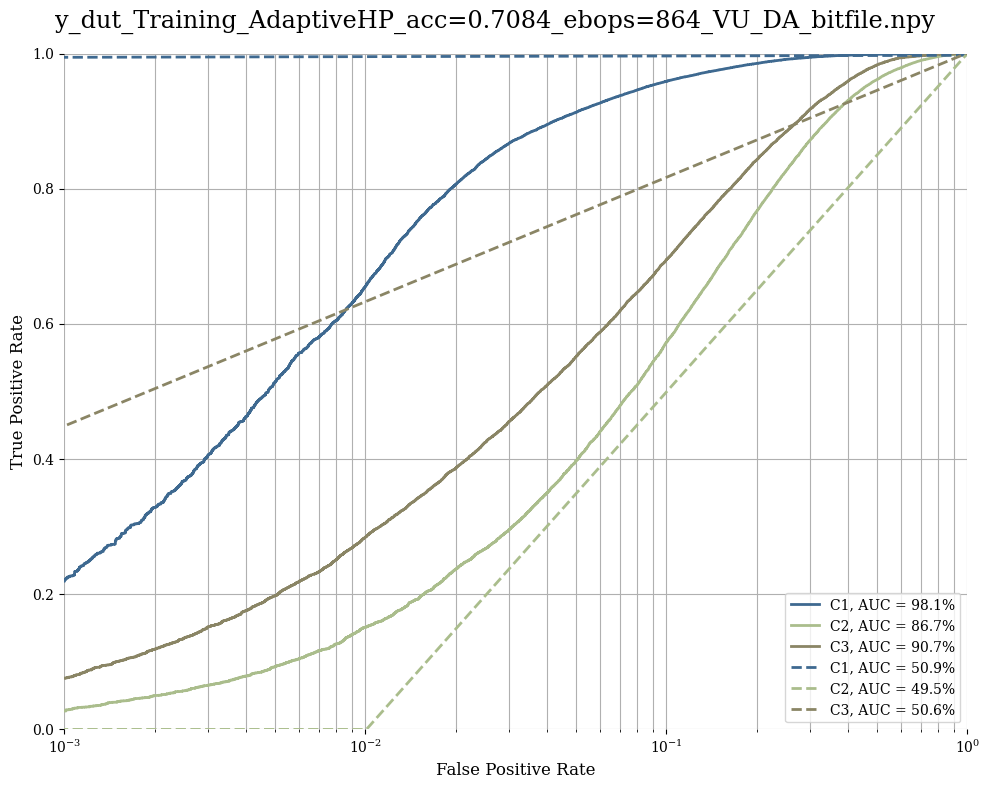

predictions/y_dut_Training_AdaptiveHP_acc=0.7573_ebops=11698_VU_latency_bitfile.npy


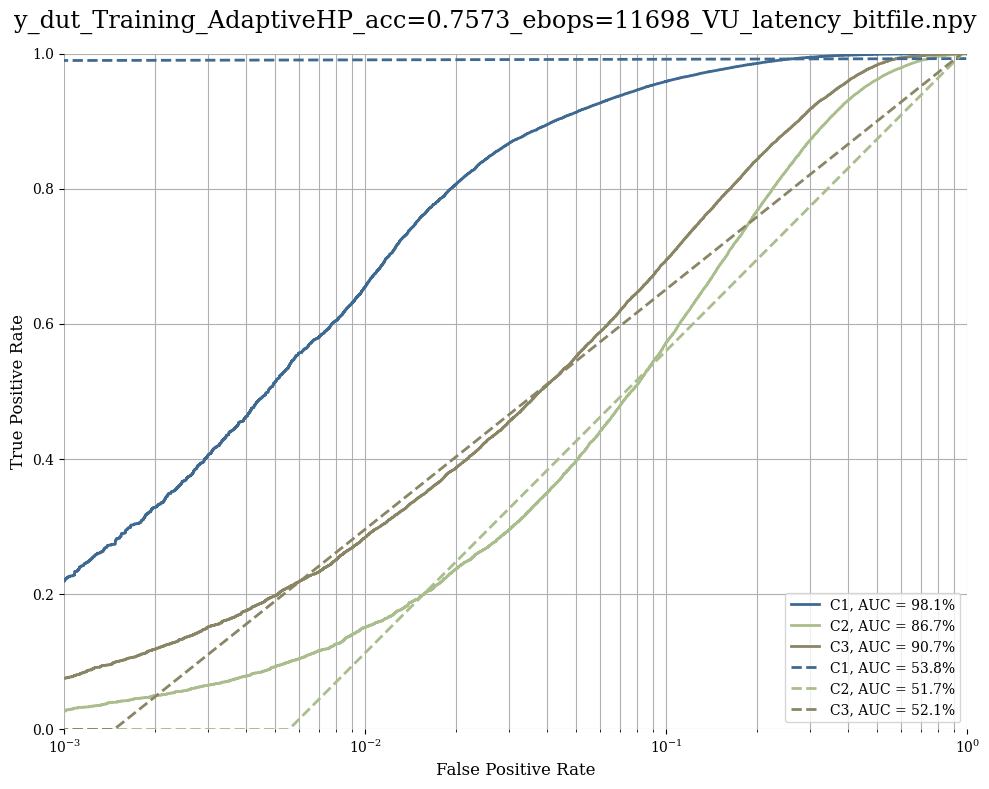

predictions/y_dut_Training_AdaptiveHP_acc=0.7573_ebops=11698_VU_DA_bitfile.npy


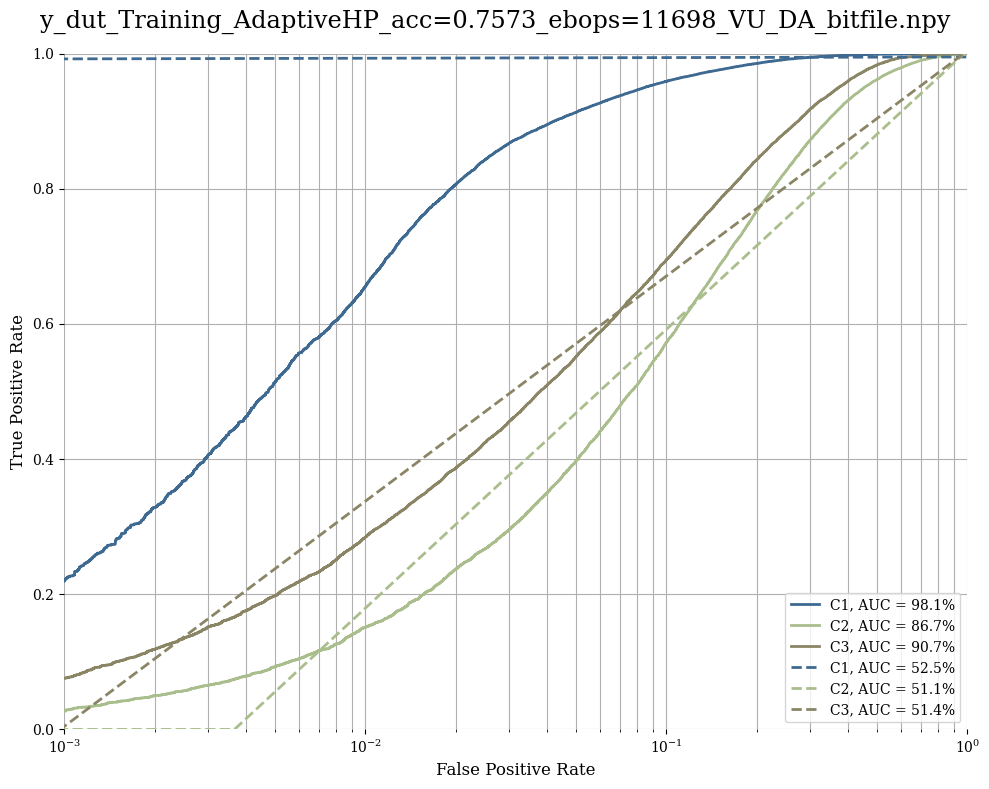

predictions/y_dut_Training_AdaptiveHP_acc=0.7084_ebops=864_VU_latency_bitfile.npy


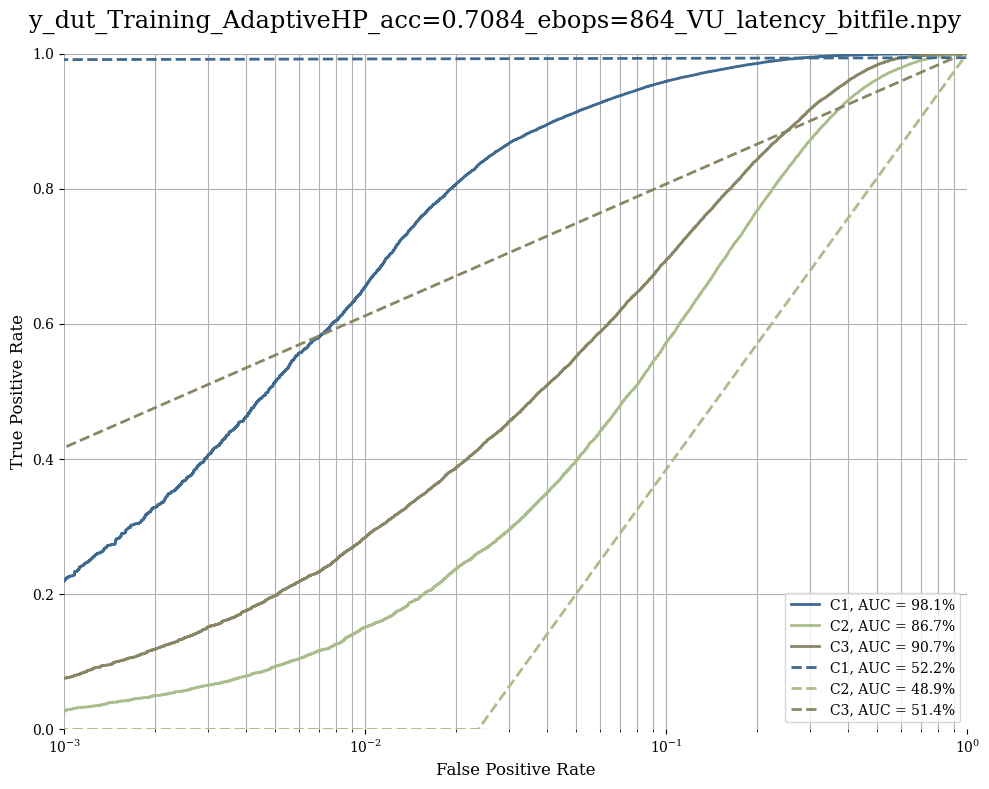

predictions/y_dut_Training_AdaptiveHP_acc=0.7449_ebops=3640_VU_DA_bitfile.npy


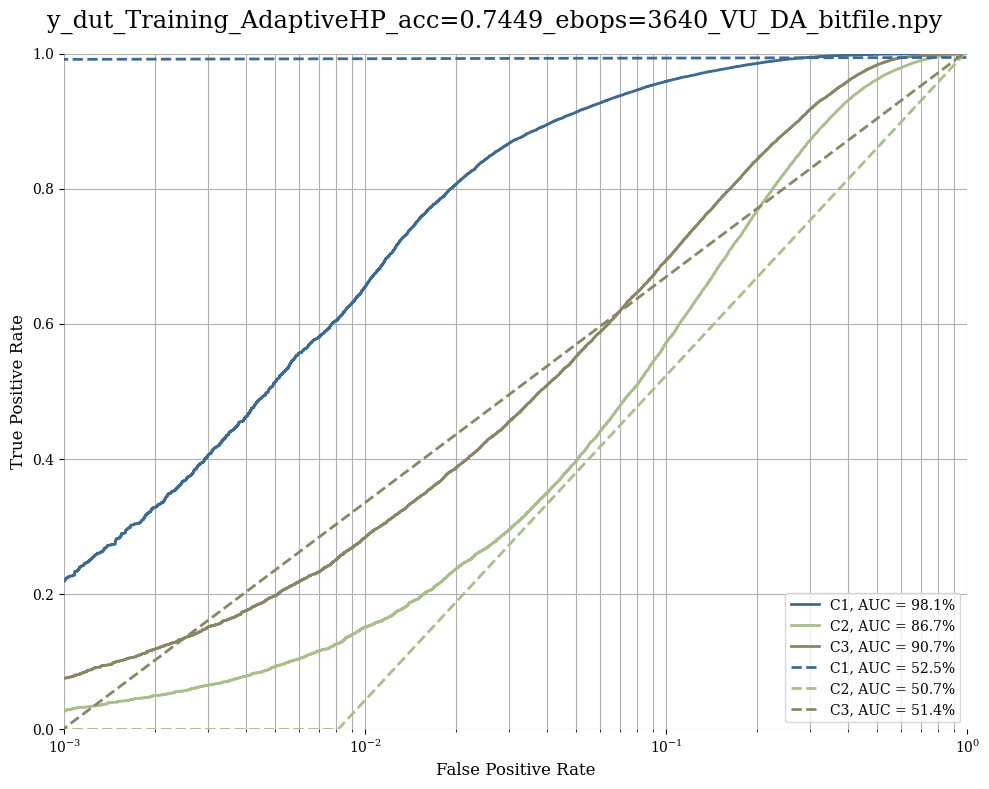

In [17]:
from pathlib import Path

paths = []
print(f"Searching for predictions in {prediction_dir}")
for prediction_path in Path(prediction_dir).rglob('*.npy'):
    print(prediction_path)
    dut_roc(prediction_path, str(prediction_path.name))
    paths.append(prediction_path)


In [13]:
for p in paths:
    print(p)

predictions/y_dut_Training_AdaptiveHP_acc=0.7084_ebops=864_VU_DA_bitfile.npy
predictions/y_dut_Training_AdaptiveHP_acc=0.7573_ebops=11698_VU_latency_bitfile.npy
predictions/y_dut_Training_AdaptiveHP_acc=0.7573_ebops=11698_VU_DA_bitfile.npy
predictions/y_dut_Training_AdaptiveHP_acc=0.7084_ebops=864_VU_latency_bitfile.npy
predictions/y_dut_Training_AdaptiveHP_acc=0.7449_ebops=3640_VU_DA_bitfile.npy


Choose the plots you want to finalize for report

In [ ]:
prediction_path = 'predictions/y_dut_Training_FixedHP_acc=0.7659_ebops=21624_VU_latency_bitfile.npy'
plotname = ''

dut_roc(prediction_path, plotname)